# Customer Churn Prediction


# Bab 1. Exploratory Data Analysis (EDA)

## 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from model_utils import TARGET_COL, RANDOM_STATE, TEST_SIZE, engineer_customer_features, align_features, split_feature_types
from train_model import (
    build_direct_preprocessor,
    build_preprocessor,
    build_models,
    run_experiment,
    get_numeric_outlier_summary,
    aggregate_feature_importance,
    select_important_features,
    evaluate_classifier,
    metrics_to_row,
    build_metadata,
)

import joblib
import warnings
warnings.filterwarnings("ignore")

## 1.2 Load Dataset

In [2]:
df = pd.read_csv("Sales - Marketing customer dataset.csv")

print("Jumlah baris dan kolom:", df.shape)
print("Nama kolom:")
print(df.columns.tolist())

Jumlah baris dan kolom: (15000, 30)
Nama kolom:
['customer_id', 'gender', 'age', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


## 1.3 Menampilkan 5 Baris Pertama

In [3]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 1.4 Informasi Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## 1.5 Statistik Deskriptif

In [5]:
df.describe(include="all")

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,...,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,1000,800,5,3,2,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,...,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,29,32,3055,5043,7666,...,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,NaN,10.334384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.421214,0.354781,1.720537,NaN,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000


## 1.6 Persentase Missing Value

In [6]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage

coupon_code                   40.886667
age                            8.000000
total_spent                    7.000000
gender                         4.920000
satisfaction_score             4.680000
customer_id                    0.000000
last_purchase_date             0.000000
acquisition_channel            0.000000
device_type                    0.000000
subscription_type              0.000000
is_premium_user                0.000000
country                        0.000000
city                           0.000000
signup_date                    0.000000
pages_per_session              0.000000
avg_session_time               0.000000
total_visits                   0.000000
email_click_rate               0.000000
avg_order_value                0.000000
discount_used                  0.000000
support_tickets                0.000000
email_open_rate                0.000000
refund_requested               0.000000
delivery_delay_days            0.000000
payment_method                 0.000000


## 1.7 Visualisasi Missing Value

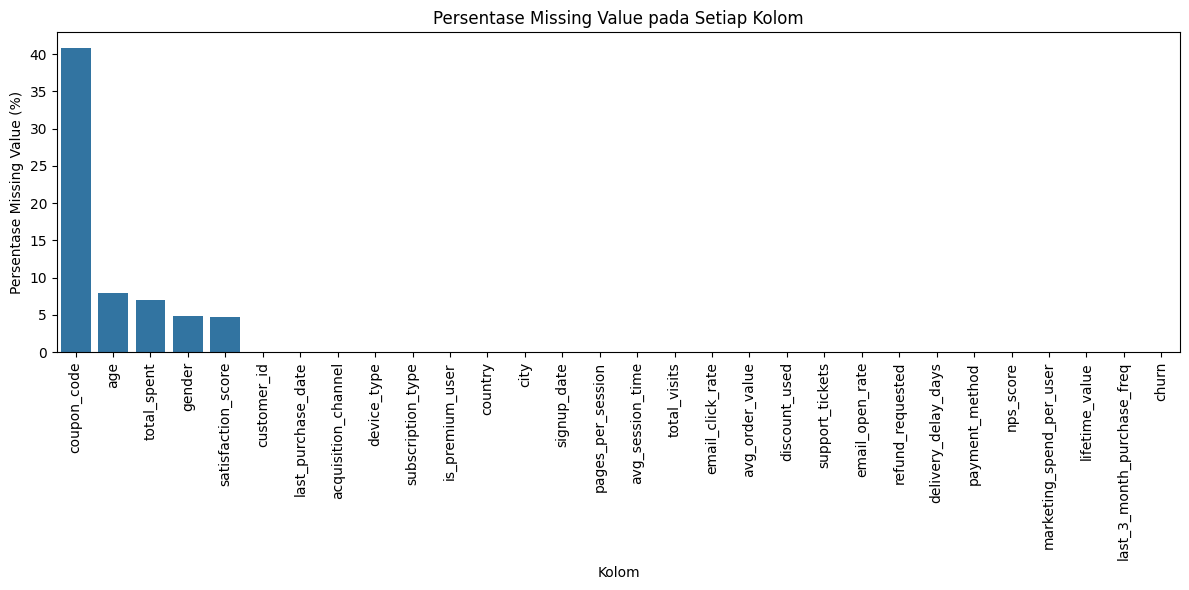

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.xticks(rotation=90)
plt.xlabel("Kolom")
plt.ylabel("Persentase Missing Value (%)")
plt.title("Persentase Missing Value pada Setiap Kolom")
plt.tight_layout()
plt.show()

## 1.8 Distribusi Variabel Target Churn

churn
0    12702
1     2298
Name: count, dtype: int64
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


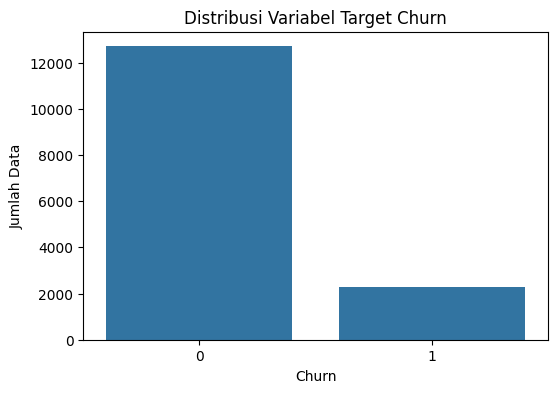

In [8]:
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.xlabel("Churn")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Variabel Target Churn")
plt.show()

## 1.9 Heatmap Korelasi Fitur Numerik

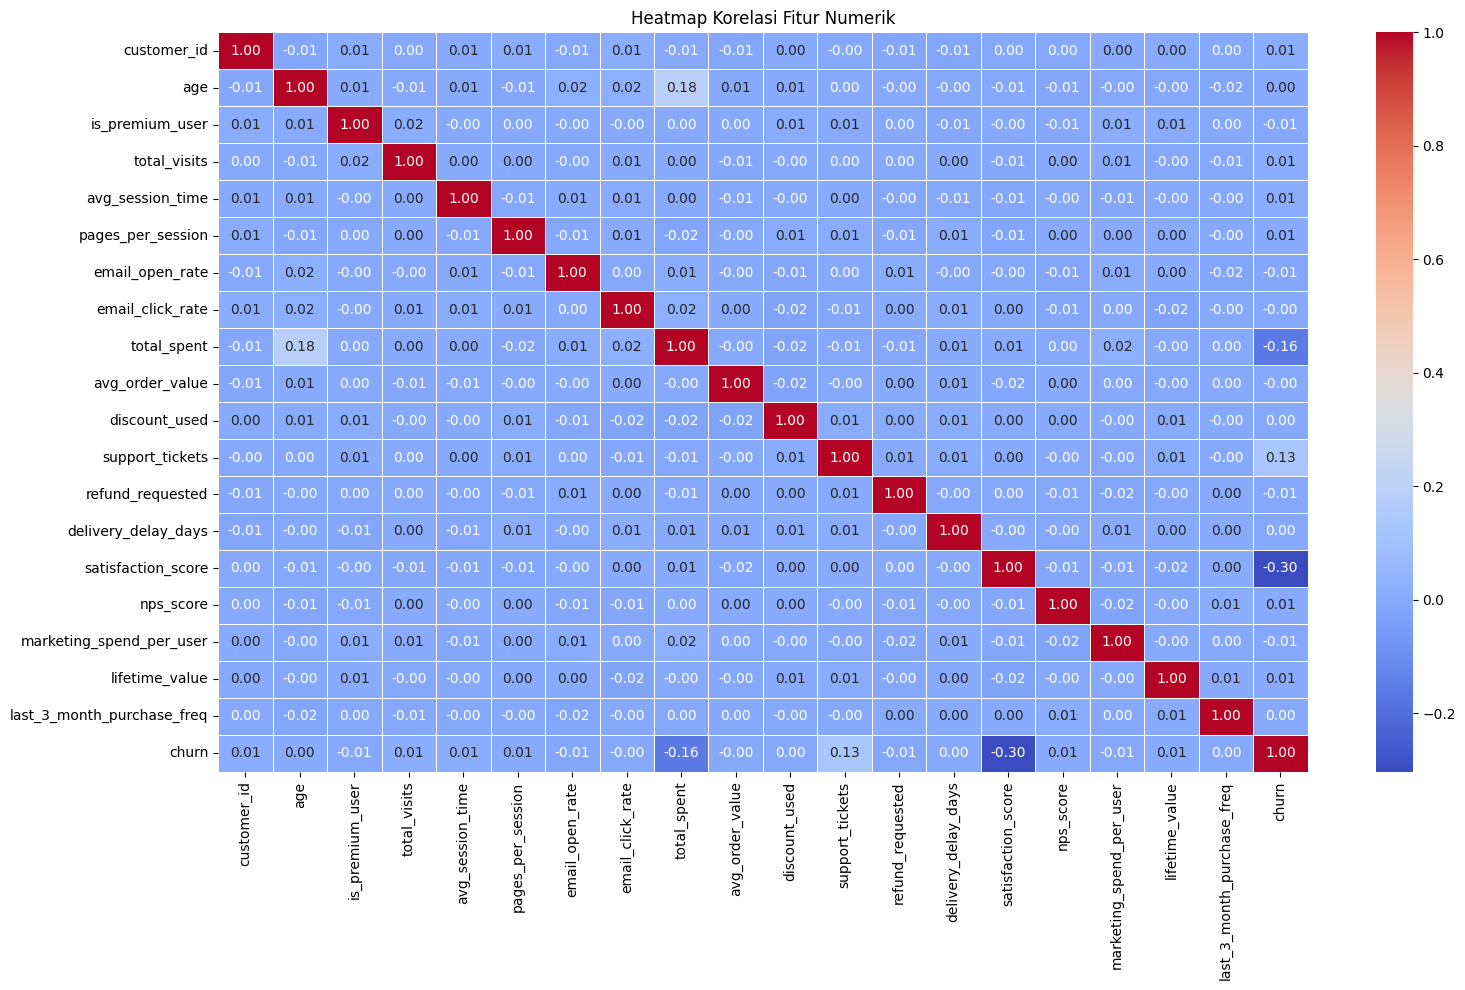

In [9]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

## 1.10 Korelasi Fitur Numerik terhadap Churn

In [10]:
correlation_matrix[TARGET_COL].sort_values(ascending=False)

churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64

# Bab 2. Direct Modeling

Pada skenario direct, data digunakan sebagai baseline tanpa cleaning, outlier handling, feature selection, scaling, dan tuning. Adapter minimal tetap digunakan agar scikit-learn dapat membaca missing value dan fitur kategorikal.

## 2.1 Menentukan X dan y

In [11]:
X_direct = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Shape X:", X_direct.shape)
print("Shape y:", y.shape)

Shape X: (15000, 29)
Shape y: (15000,)


## 2.2 Train-Test Split

In [12]:
X_train_direct, X_test_direct, y_train, y_test = train_test_split(
    X_direct,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Data latih:", X_train_direct.shape)
print("Data uji:", X_test_direct.shape)

Data latih: (12000, 29)
Data uji: (3000, 29)


## 2.3 Training 3 Model Direct

In [13]:
direct_models = build_models(
    build_direct_preprocessor(X_train_direct),
    class_weight="balanced",
)

direct_rows, direct_fitted = run_experiment(
    "Direct Modeling",
    direct_models,
    X_train_direct,
    X_test_direct,
    y_train,
    y_test,
)

direct_results_df = pd.DataFrame(direct_rows)
direct_results_df


Scenario: Direct Modeling | Model: Logistic Regression
Accuracy : 0.7540
Precision: 0.3546
Recall   : 0.7370
F1-score : 0.4788
Confusion matrix:
[[1923  617]
 [ 121  339]]

Scenario: Direct Modeling | Model: Random Forest
Accuracy : 0.8507
Precision: 0.5300
Recall   : 0.2304
F1-score : 0.3212
Confusion matrix:
[[2446   94]
 [ 354  106]]

Scenario: Direct Modeling | Model: Voting Classifier
Accuracy : 0.8583
Precision: 0.5397
Recall   : 0.5174
F1-score : 0.5283
Confusion matrix:
[[2337  203]
 [ 222  238]]


,scenario,model,accuracy,precision,recall,f1_score
0,Direct Modeling,Logistic Regression,0.754000,0.354603,0.736957,0.478814
1,Direct Modeling,Random Forest,0.850667,0.530000,0.230435,0.321212
2,Direct Modeling,Voting Classifier,0.858333,0.539683,0.517391,0.528302


# Bab 3. Modeling Dengan Preprocessing

## 3.1 Pembersihan Data, Feature Engineering, dan Penghapusan Kolom Tidak Relevan

In [14]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi:", duplicate_count)

df_model = engineer_customer_features(df)
df_model = df_model.drop_duplicates().reset_index(drop=True)

print("Shape setelah preprocessing awal:", df_model.shape)
df_model.head()

Jumlah duplikasi: 0
Shape setelah preprocessing awal: (15000, 34)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,lifetime_value,last_3_month_purchase_freq,churn,customer_tenure_days,recency_days,signup_month,signup_year,last_purchase_month,last_purchase_year,last_purchase_dayofweek
0,Male,52.0,India,Berlin,Email,Tablet,Annual,1,7,13.903745,...,915.310827,14,0,966,69,5,2022,12,2024,1
1,NaN,35.0,Germany,Mumbai,Organic,Desktop,Monthly,0,19,5.112528,...,2079.960938,11,0,-40,307,6,2024,5,2024,1
2,Female,27.0,Germany,London,Email,Mobile,Annual,1,18,9.742749,...,1379.150885,9,0,249,316,8,2023,4,2024,6
3,Female,36.0,India,Mumbai,Facebook Ads,Tablet,Annual,1,16,9.642654,...,774.652684,7,0,-253,660,1,2024,5,2023,5
4,Male,29.0,USA,Hamburg,Referral,Mobile,Monthly,0,12,7.791291,...,87.680409,11,0,261,337,7,2023,4,2024,6


## 3.2 Menentukan X dan y Setelah Preprocessing

In [15]:
X_clean = df_model.drop(columns=[TARGET_COL])
y_clean = df_model[TARGET_COL]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clean,
)

print("Data latih:", X_train_clean.shape)
print("Data uji:", X_test_clean.shape)

Data latih: (12000, 33)
Data uji: (3000, 33)


## 3.3 Ringkasan Outlier pada Data Latih

In [16]:
outlier_summary_df = get_numeric_outlier_summary(X_train_clean)
outlier_summary_df

,feature,lower_bound,upper_bound,outlier_count_train,outlier_percentage_train
10,satisfaction_score,1.500000,5.500000,609,5.08
9,delivery_delay_days,-1.000000,7.000000,148,1.23
0,age,7.000000,63.000000,69,0.57
8,support_tickets,-2.000000,6.000000,68,0.57
6,total_spent,-304.365784,1308.474377,61,0.51
7,avg_order_value,-7.582443,127.064478,50,0.42
13,lifetime_value,-682.287707,3097.150003,43,0.36
2,avg_session_time,-0.128848,16.176700,37,0.31
1,total_visits,3.000000,27.000000,31,0.26
3,pages_per_session,-0.034348,8.058550,30,0.25


## 3.4 Training 3 Model Dengan Preprocessing

In [17]:
preprocessing_models = build_models(
    build_preprocessor(X_train_clean),
    class_weight="balanced",
)

preprocessing_rows, preprocessing_fitted = run_experiment(
    "Preprocessing",
    preprocessing_models,
    X_train_clean,
    X_test_clean,
    y_train_clean,
    y_test_clean,
)

preprocessing_results_df = pd.DataFrame(preprocessing_rows)
preprocessing_results_df


Scenario: Preprocessing | Model: Logistic Regression
Accuracy : 0.7443
Precision: 0.3435
Recall   : 0.7326
F1-score : 0.4677
Confusion matrix:
[[1896  644]
 [ 123  337]]

Scenario: Preprocessing | Model: Random Forest
Accuracy : 0.8477
Precision: 0.5263
Recall   : 0.0652
F1-score : 0.1161
Confusion matrix:
[[2513   27]
 [ 430   30]]

Scenario: Preprocessing | Model: Voting Classifier
Accuracy : 0.8460
Precision: 0.4977
Recall   : 0.4696
F1-score : 0.4832
Confusion matrix:
[[2322  218]
 [ 244  216]]


,scenario,model,accuracy,precision,recall,f1_score
0,Preprocessing,Logistic Regression,0.744333,0.343527,0.732609,0.467731
1,Preprocessing,Random Forest,0.847667,0.526316,0.065217,0.116054
2,Preprocessing,Voting Classifier,0.846000,0.497696,0.469565,0.483221


# Bab 4. Hyperparameter Tuning dan Feature Selection

## 4.1 Feature Importance

In [18]:
rf_importance_model = preprocessing_fitted["Random Forest"]["estimator"]
_, categorical_features_clean = split_feature_types(X_train_clean)

feature_importance_df = aggregate_feature_importance(
    rf_importance_model,
    categorical_features_clean,
)

feature_importance_df.head(20)

,feature,importance,cumulative_importance
0,satisfaction_score,0.201108,0.201108
1,total_spent,0.193495,0.394603
2,support_tickets,0.073275,0.467878
3,signup_month,0.028731,0.496608
4,pages_per_session,0.027820,0.524428
5,last_purchase_month,0.027728,0.552156
6,avg_session_time,0.027528,0.579684
7,marketing_spend_per_user,0.027325,0.607009
8,avg_order_value,0.027196,0.634205
9,lifetime_value,0.026934,0.661139


## 4.2 Visualisasi Feature Importance

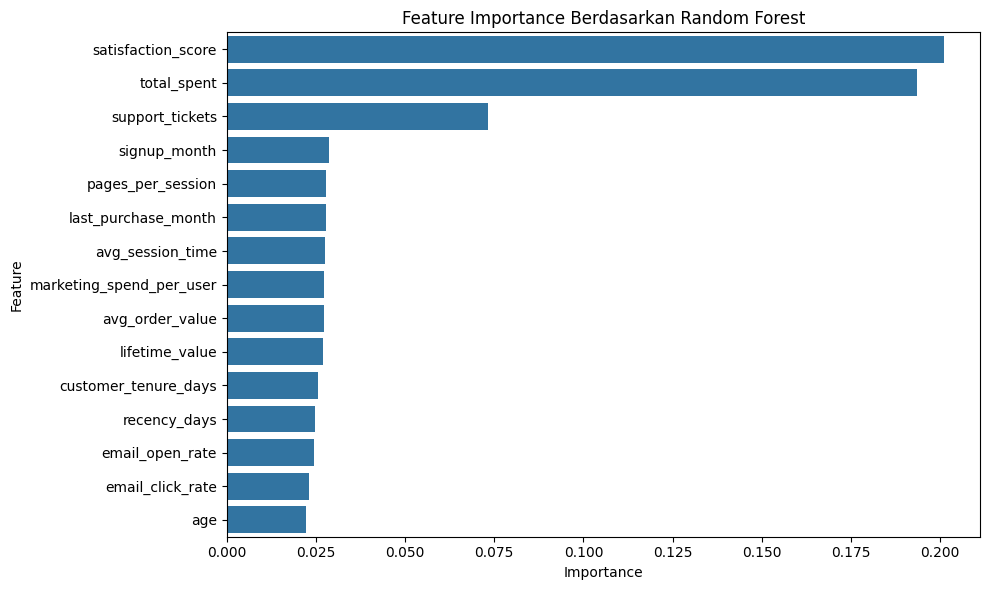

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="importance",
    y="feature",
)
plt.title("Feature Importance Berdasarkan Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 4.3 Feature Selection

In [20]:
selected_features = select_important_features(feature_importance_df)

X_train_selected = align_features(X_train_clean, selected_features)
X_test_selected = align_features(X_test_clean, selected_features)

numeric_selected, categorical_selected = split_feature_types(X_train_selected)

print("Jumlah fitur awal:", X_train_clean.shape[1])
print("Jumlah fitur terpilih:", len(selected_features))
print("Fitur terpilih:")
print(selected_features)

Jumlah fitur awal: 33
Jumlah fitur terpilih: 10
Fitur terpilih:
['satisfaction_score', 'total_spent', 'support_tickets', 'signup_month', 'pages_per_session', 'last_purchase_month', 'avg_session_time', 'marketing_spend_per_user', 'avg_order_value', 'lifetime_value']


## 4.4 Grid Search Hyperparameter

In [21]:
selected_preprocessor = build_preprocessor(X_train_selected)
grid_models = build_models(
    selected_preprocessor,
    class_weight="balanced",
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

parameter_grids = {}

for model_name, estimator in grid_models.items():
    estimator_step = estimator.steps[-1][0]
    estimator_object = estimator.steps[-1][1]

    if model_name == "Logistic Regression":
        parameter_grids[model_name] = [
            {
                f"{estimator_step}__C": [0.01, 0.1, 1, 10],
                f"{estimator_step}__penalty": ["l1", "l2"],
                f"{estimator_step}__solver": ["liblinear"],
                f"{estimator_step}__max_iter": [1000],
            }
        ]
    elif model_name == "Decision Tree":
        parameter_grids[model_name] = {
            f"{estimator_step}__criterion": ["gini", "entropy"],
            f"{estimator_step}__max_depth": [None, 5, 10, 20],
            f"{estimator_step}__min_samples_split": [2, 5, 10],
            f"{estimator_step}__min_samples_leaf": [1, 2, 4],
        }
    elif model_name == "Random Forest":
        parameter_grids[model_name] = {
            f"{estimator_step}__n_estimators": [100, 200],
            f"{estimator_step}__max_depth": [None, 10, 20],
            f"{estimator_step}__min_samples_split": [2, 5],
            f"{estimator_step}__min_samples_leaf": [1, 2],
            f"{estimator_step}__max_features": ["sqrt", "log2"],
        }
    elif model_name == "Voting Classifier":
        n_estimators = len(estimator_object.estimators)
        voting_weights = [None]

        for index in range(n_estimators):
            weight = [1] * n_estimators
            weight[index] = 2
            voting_weights.append(weight)

        parameter_grids[model_name] = {
            f"{estimator_step}__voting": ["hard", "soft"],
            f"{estimator_step}__weights": voting_weights,
        }

best_estimators = {}
grid_search_rows = []

for model_name, estimator in grid_models.items():
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grids[model_name],
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1,
        refit=True,
    )

    grid_search.fit(X_train_selected, y_train_clean)

    best_estimators[model_name] = grid_search.best_estimator_
    grid_search_rows.append(
        {
            "model": model_name,
            "best_score": grid_search.best_score_,
            "best_params": grid_search.best_params_,
        }
    )

tuning_results_df = pd.DataFrame(grid_search_rows)
tuning_results_df = tuning_results_df.sort_values("best_score", ascending=False).reset_index(drop=True)
tuning_results_df


,model,best_score,best_params
0,Random Forest,0.660785,"{'model__max_depth': 10, 'model__max_features'..."
1,Voting Classifier,0.523291,"{'model__voting': 'soft', 'model__weights': [2..."
2,Logistic Regression,0.480087,"{'model__C': 10, 'model__max_iter': 1000, 'mod..."


## 4.5 Evaluasi Best Estimator Hasil Grid Search

In [22]:
tuning_rows = []
tuning_metrics_by_model = {}

for model_name, estimator in best_estimators.items():
    metrics = evaluate_classifier(estimator, X_test_selected, y_test_clean)
    tuning_rows.append(metrics_to_row("Grid Search + Feature Selection", model_name, metrics))
    tuning_metrics_by_model[model_name] = metrics

    print("=" * 60)
    print(model_name)
    print("Accuracy :", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print("F1-score :", metrics["f1_score"])
    print("Confusion Matrix:")
    print(np.asarray(metrics["confusion_matrix"]))
    print()

tuned_results_df = pd.DataFrame(tuning_rows)
tuned_results_df

Logistic Regression
Accuracy : 0.746
Precision: 0.34685598377281945
Recall   : 0.7434782608695653
F1-score : 0.4730290456431535
Confusion Matrix:
[[1896  644]
 [ 118  342]]

Random Forest
Accuracy : 0.8543333333333333
Precision: 0.5130237825594564
Recall   : 0.9847826086956522
F1-score : 0.6746090841399851
Confusion Matrix:
[[2110  430]
 [   7  453]]

Voting Classifier
Accuracy : 0.8496666666666667
Precision: 0.5087040618955513
Recall   : 0.5717391304347826
F1-score : 0.5383828045035824
Confusion Matrix:
[[2286  254]
 [ 197  263]]



,scenario,model,accuracy,precision,recall,f1_score
0,Grid Search + Feature Selection,Logistic Regression,0.746000,0.346856,0.743478,0.473029
1,Grid Search + Feature Selection,Random Forest,0.854333,0.513024,0.984783,0.674609
2,Grid Search + Feature Selection,Voting Classifier,0.849667,0.508704,0.571739,0.538383


## 4.6 Ringkasan Total 9 Model

In [23]:
all_results_df = pd.concat(
    [direct_results_df, preprocessing_results_df, tuned_results_df],
    ignore_index=True,
)

all_results_df.sort_values("f1_score", ascending=False)

,scenario,model,accuracy,precision,recall,f1_score
7,Grid Search + Feature Selection,Random Forest,0.854333,0.513024,0.984783,0.674609
8,Grid Search + Feature Selection,Voting Classifier,0.849667,0.508704,0.571739,0.538383
2,Direct Modeling,Voting Classifier,0.858333,0.539683,0.517391,0.528302
5,Preprocessing,Voting Classifier,0.846000,0.497696,0.469565,0.483221
0,Direct Modeling,Logistic Regression,0.754000,0.354603,0.736957,0.478814
6,Grid Search + Feature Selection,Logistic Regression,0.746000,0.346856,0.743478,0.473029
3,Preprocessing,Logistic Regression,0.744333,0.343527,0.732609,0.467731
1,Direct Modeling,Random Forest,0.850667,0.530000,0.230435,0.321212
4,Preprocessing,Random Forest,0.847667,0.526316,0.065217,0.116054


# Bab 5. Deployment ke Streamlit Cloud

## 5.1 Simpan Model Terbaik dan Metadata

In [24]:
best_row = all_results_df.sort_values("f1_score", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_scenario = best_row["scenario"]

if best_scenario == "Grid Search + Feature Selection":
    best_model = best_estimators[best_model_name]
    best_metrics = tuning_metrics_by_model[best_model_name]
    best_params = tuning_results_df.loc[tuning_results_df["model"] == best_model_name, "best_params"].iloc[0]
    final_features = selected_features
    final_numeric = numeric_selected
    final_categorical = categorical_selected
else:
    raise ValueError("Model terbaik sebaiknya berasal dari skenario grid search untuk deployment final.")

reference_date = pd.to_datetime(df["last_purchase_date"], errors="coerce").max()
metadata = build_metadata(
    df_raw=df,
    df_model=df_model,
    selected_features=final_features,
    numeric_features=final_numeric,
    categorical_features=final_categorical,
    best_model_name=best_model_name,
    best_metrics=best_metrics,
    best_params=best_params,
    results_df=all_results_df,
    feature_importance_df=feature_importance_df,
    reference_date=reference_date,
)
metadata["best_scenario"] = best_scenario

joblib.dump(best_model, "best_model.joblib")
joblib.dump(metadata, "model_metadata.joblib")

print("Model terbaik:", best_model_name)
print("Skenario:", best_scenario)
print("File best_model.joblib dan model_metadata.joblib berhasil dibuat.")

Model terbaik: Random Forest
Skenario: Grid Search + Feature Selection
File best_model.joblib dan model_metadata.joblib berhasil dibuat.
